# 05 - LSTM per-meal glucose prediction

Build a sequence model that reads **24 five-minute CGM readings** (the 2-hour window before each meal) and predicts `peak_delta` (mg/dL post-meal rise).

### Why a sequence model?
The tabular models in notebook 01 compress the pre-meal CGM history into three scalar summary features (`pre_meal_glucose`, `glucose_velocity_30min`, `glucose_60min_before_mean`). An LSTM can instead learn *patterns* in the 2-hour trajectory - e.g. "already rising when the meal starts" vs "flat but with a recent dip" - that scalars cannot capture.

### Honest expectations with n=295
An LSTM needs far more data than 295 meals to generalise reliably. This notebook:
- Builds the full infrastructure (sequence construction, model, training loop, evaluation)
- Quantifies *how much* the model overfits today
- Draws a data-collection roadmap for when it becomes viable

## 1. Setup & imports

In [60]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# PyTorch - install from root requirements.txt if missing
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    torch.manual_seed(SEED)
    print(f"PyTorch {torch.__version__}  CUDA={torch.cuda.is_available()}")
except ImportError:
    raise SystemExit("PyTorch not found. Run: pip install torch --index-url https://download.pytorch.org/whl/cpu")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (11, 5)

DATA_DIR  = os.path.abspath(os.path.join('..', 'data'))
MODEL_DIR = os.path.abspath(os.path.join('..', 'models'))
os.makedirs(MODEL_DIR, exist_ok=True)

PyTorch 2.12.0+cpu  CUDA=False


## 2. Load per-meal labels

In [ ]:
df = pd.read_csv(
    os.path.join(DATA_DIR, 'processed', 'per_meal_features.csv'),
    parse_dates=['ts']
)
df = df.dropna(subset=['peak_delta']).sort_values('ts').reset_index(drop=True)
TARGET = 'peak_delta'

print(f"Total meals with peak_delta: {len(df)}")
print(f"Date range: {df['ts'].min().date()} -> {df['ts'].max().date()}")
print(f"peak_delta  mean={df[TARGET].mean():.1f}  std={df[TARGET].std():.1f}  "
      f"min={df[TARGET].min():.1f}  max={df[TARGET].max():.1f}")

Total meals with peak_delta: 295
Date range: 2026-02-01 → 2026-04-28
peak_delta  mean=75.6  std=38.1  min=0.0  max=201.0


## 3. Load CGM readings

In [ ]:
cgm_path = os.path.join(DATA_DIR, 'raw', 'cgm_5min.csv')
cgm_df = pd.read_csv(cgm_path, parse_dates=['ts'], usecols=['ts', 'glucose_mg_dl'])
cgm_df = cgm_df.dropna(subset=['glucose_mg_dl']).sort_values('ts').set_index('ts')

print(f"CGM readings loaded: {len(cgm_df):,}")
print(f"Date range: {cgm_df.index.min().date()} -> {cgm_df.index.max().date()}")

# Verify expected density (~1 reading per 5 min)
span_min = (cgm_df.index.max() - cgm_df.index.min()).total_seconds() / 60
expected = span_min / 5
coverage = len(cgm_df) / expected * 100
print(f"Coverage: {len(cgm_df):,} / {expected:,.0f} expected = {coverage:.1f}%")

CGM readings loaded: 22,178
Date range: 2026-02-01 → 2026-04-28
Coverage: 22,178 / 24,892 expected = 89.1%


## 4. Build pre-meal sequences

For each meal, extract the 24 five-minute CGM readings in the 2-hour window immediately before meal time. If a reading is missing (sensor gap), interpolate linearly over time. If fewer than 12 of the 24 readings are present (≥ 50% gap), skip that meal.

**Why 24 readings (2 hours)?**
- Post-prandial glucose peaks at 45–90 min; the pre-meal 2-hour trajectory captures fasting trend, dawn effect, and recent activity impact.
- Shorter windows miss drift; longer windows (4 h) are dominated by the previous meal.


In [63]:
SEQ_LEN = 24   # 24 × 5-min = 2-hour window

sequences, targets, meal_ts = [], [], []

for _, row in df.iterrows():
    meal_time    = pd.Timestamp(row['ts'])
    window_start = meal_time - pd.Timedelta(minutes=SEQ_LEN * 5)

    seg = cgm_df.loc[window_start:meal_time, 'glucose_mg_dl'].dropna()

    if len(seg) < SEQ_LEN // 2:   # skip if > 50% of window is missing
        continue

    # Resample to exactly SEQ_LEN evenly-spaced points
    idx_even = pd.date_range(end=meal_time, periods=SEQ_LEN, freq='5min')
    seg_reindexed = (
        seg.reindex(seg.index.union(idx_even))
           .interpolate('time')
           .reindex(idx_even)
    )
    if seg_reindexed.isna().any():
        continue

    sequences.append(seg_reindexed.values.astype(np.float32))
    targets.append(float(row[TARGET]))
    meal_ts.append(meal_time)

n = len(sequences)
print(f"Meals with valid sequences: {n} / {len(df)} ({n/len(df)*100:.1f}%)")
print(f"Skipped (insufficient CGM coverage): {len(df) - n}")

Meals with valid sequences: 283 / 295 (95.9%)
Skipped (insufficient CGM coverage): 12


## 5. Coverage analysis & sequence quality

Sequence array shape: (283, 24)
Glucose in sequences - mean: 159.6  std: 43.8  min: 68.0  max: 315.2


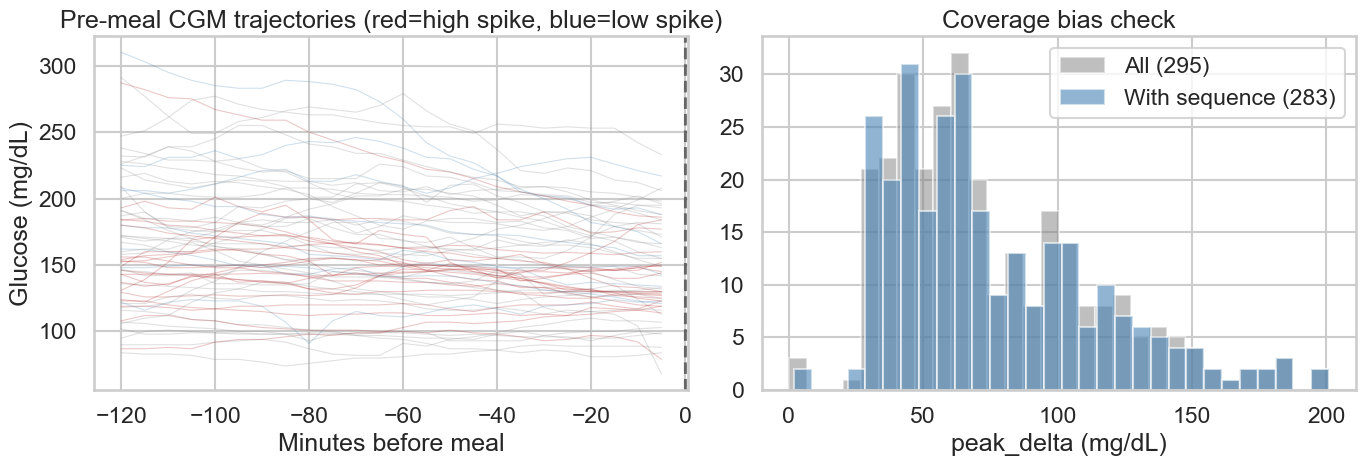


Coverage bias (mean peak_delta):
  All meals:           75.6 mg/dL
  With sequence:       76.0 mg/dL


In [64]:
X_raw = np.stack(sequences)   # (N, SEQ_LEN)
y_raw = np.array(targets, dtype=np.float32)

print(f"Sequence array shape: {X_raw.shape}")
print(f"Glucose in sequences - mean: {X_raw.mean():.1f}  std: {X_raw.std():.1f}  "
      f"min: {X_raw.min():.1f}  max: {X_raw.max():.1f}")

# Plot a sample of pre-meal CGM trajectories coloured by peak_delta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample 60 random meals
rng = np.random.default_rng(0)
idx_sample = rng.choice(n, size=min(60, n), replace=False)
t_axis = np.arange(-SEQ_LEN * 5, 0, 5)   # minutes before meal

for i in idx_sample:
    colour = 'firebrick' if y_raw[i] > 80 else ('steelblue' if y_raw[i] < 40 else '#888')
    axes[0].plot(t_axis, X_raw[i], alpha=0.25, color=colour, linewidth=0.8)

axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='meal time')
axes[0].set_xlabel('Minutes before meal'); axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_title('Pre-meal CGM trajectories (red=high spike, blue=low spike)')

# Distribution of peak_delta for meals with vs without valid sequences
skip_mask = ~df['ts'].isin([t.to_pydatetime() for t in meal_ts])
axes[1].hist(df[TARGET], bins=30, alpha=0.5, label=f'All ({len(df)})', color='gray')
axes[1].hist(y_raw, bins=30, alpha=0.6, label=f'With sequence ({n})', color='steelblue')
axes[1].set_xlabel('peak_delta (mg/dL)'); axes[1].set_title('Coverage bias check')
axes[1].legend()
plt.tight_layout(); plt.show()

print("\nCoverage bias (mean peak_delta):")
print(f"  All meals:           {df[TARGET].mean():.1f} mg/dL")
print(f"  With sequence:       {y_raw.mean():.1f} mg/dL")

## 6. Temporal train / test split & normalisation

Same 21-day holdout as notebook 01. Glucose values are normalised to zero-mean unit-variance using **training-set statistics only** (prevent data leakage from the test set).


In [65]:
HOLDOUT_DAYS = 21

split_ts   = max(meal_ts) - pd.Timedelta(days=HOLDOUT_DAYS)
train_mask = np.array([t <= split_ts for t in meal_ts])
test_mask  = ~train_mask

X_train_raw, X_test_raw = X_raw[train_mask], X_raw[test_mask]
y_train_log = np.log1p(np.clip(y_raw[train_mask], 0, None))
y_test_log  = np.log1p(np.clip(y_raw[test_mask],  0, None))
y_test_orig = np.clip(y_raw[test_mask], 0, None)

print(f"Train: {train_mask.sum()} meals  |  Test: {test_mask.sum()} meals")
print(f"Split date: {split_ts.date()}")

# Normalise using training statistics (per-element mean/std across all sequences & timesteps)
mu  = X_train_raw.mean()
sig = X_train_raw.std() + 1e-6
X_train = (X_train_raw - mu) / sig
X_test  = (X_test_raw  - mu) / sig

print(f"\nNormalised train glucose - mean: {X_train.mean():.3f}  std: {X_train.std():.3f}")

Train: 207 meals  |  Test: 76 meals
Split date: 2026-04-07

Normalised train glucose - mean: -0.000  std: 1.000


## 7. PyTorch Dataset & DataLoader

In [ ]:
# Add feature dimension: (N, SEQ_LEN) -> (N, SEQ_LEN, 1)
Xt = torch.tensor(X_train[:, :, None])   # (N_train, 24, 1)
yt = torch.tensor(y_train_log)

dataset = TensorDataset(Xt, yt)
loader  = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=False,
                     generator=torch.Generator().manual_seed(SEED))

print(f"Training batches per epoch: {len(loader)}")
print(f"Input tensor shape (one batch): {next(iter(loader))[0].shape}")

Training batches per epoch: 13
Input tensor shape (one batch): torch.Size([16, 24, 1])


## 8. LSTM model definition

Architecture:
- **Input**: 1 feature (normalised glucose) × 24 timesteps
- **LSTM**: 2 layers, 32 hidden units, 20% dropout between layers
- **Output**: Linear layer → scalar (log1p peak_delta)

This is intentionally small to reduce overfitting on 200-ish training samples.


In [67]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        return self.fc(out[:, -1, :]).squeeze(-1)   # last timestep

model = LSTMRegressor()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

LSTMRegressor(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 12,961


## 9. Training loop

In [68]:
EPOCHS   = 150
LR       = 1e-3
WD       = 1e-4
PATIENCE = 20    # early-stopping: epochs without val-loss improvement

optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
criterion = nn.MSELoss()

# Validation split: last 15% of training set by time (no leakage from test)
val_n  = max(5, int(train_mask.sum() * 0.15))
Xt_sub = Xt[:-val_n];  yt_sub = yt[:-val_n]
Xv     = Xt[-val_n:];  yv     = yt[-val_n:]

sub_loader = DataLoader(
    TensorDataset(Xt_sub, yt_sub), batch_size=16, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_state    = None
wait          = 0

model.train()
for epoch in range(EPOCHS):
    ep_loss = 0.0
    for xb, yb in sub_loader:
        optimiser.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimiser.step()
        ep_loss += loss.item() * len(xb)
    train_losses.append(ep_loss / len(Xt_sub))

    model.eval()
    with torch.no_grad():
        vl = criterion(model(Xv), yv).item()
    val_losses.append(vl)
    model.train()

    # Track best weights
    if vl < best_val_loss:
        best_val_loss = vl
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stop at epoch {epoch+1}  (no val improvement for {PATIENCE} epochs)")
            break

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}")

# Restore best checkpoint
model.load_state_dict(best_state)
print(f"\nTraining complete.  Best val loss: {best_val_loss:.4f}  (weights restored)")

Epoch  30/150  train=0.2972  val=0.1220
Early stop at epoch 55  (no val improvement for 20 epochs)

Training complete.  Best val loss: 0.1136  (weights restored)


## 10. Learning curves - diagnosing the train/val gap

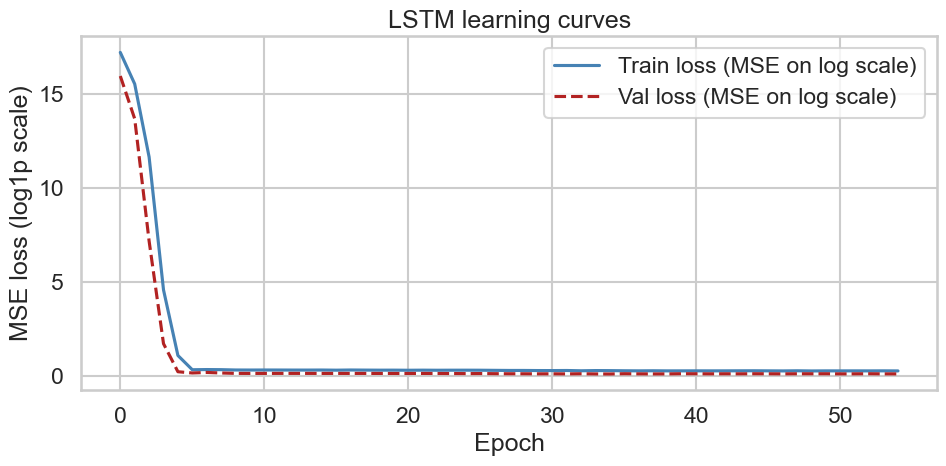


Final train loss: 0.2777
Final val   loss: 0.1196
Overfit ratio (val/train): 0.43x

Interpretation:
  ratio ~ 1.0 → no overfit (model too simple, or data too noisy)
  ratio   1-2 → mild overfit - acceptable with this sample size
  ratio > 2.0 → significant overfit - more data needed before trusting test predictions


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train loss (MSE on log scale)', color='steelblue')
ax.plot(val_losses,   label='Val loss (MSE on log scale)',   color='firebrick', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss (log1p scale)')
ax.set_title('LSTM learning curves')
ax.legend()
plt.tight_layout(); plt.show()

print(f"\nFinal train loss: {train_losses[-1]:.4f}")
print(f"Final val   loss: {val_losses[-1]:.4f}")
print(f"Overfit ratio (val/train): {val_losses[-1]/train_losses[-1]:.2f}x")
print()
print("Interpretation:")
print("  ratio ~ 1.0 -> no overfit (model too simple, or data too noisy)")
print("  ratio   1-2 -> mild overfit - acceptable with this sample size")
print("  ratio > 2.0 -> significant overfit - more data needed before trusting test predictions")

## 11. Evaluation on held-out test set

LSTM - Train RMSE: 36.76  Test RMSE: 33.65  MAE: 25.15  R²: 0.170


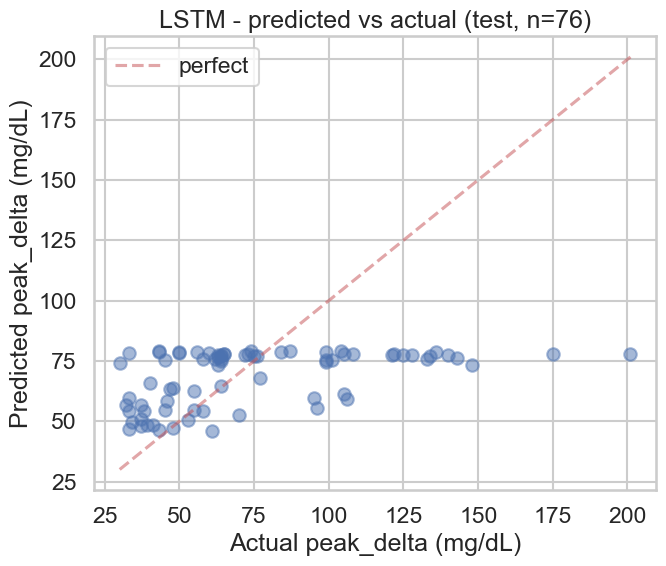

In [70]:
model.eval()
with torch.no_grad():
    Xte      = torch.tensor(X_test[:, :, None])
    pred_log = model(Xte).numpy()
    pred_te  = np.expm1(pred_log)

    # Re-run on full train set for train RMSE
    pred_tr_log = model(Xt).numpy()
    pred_tr     = np.expm1(pred_tr_log)
    y_tr_orig   = np.expm1(y_train_log)

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))

rmse_tr = rmse(y_tr_orig, pred_tr)
rmse_te = rmse(y_test_orig, pred_te)
mae_te  = float(mean_absolute_error(y_test_orig, pred_te))
r2_te   = float(r2_score(y_test_orig, pred_te))

print(f"LSTM - Train RMSE: {rmse_tr:.2f}  Test RMSE: {rmse_te:.2f}  "
      f"MAE: {mae_te:.2f}  R²: {r2_te:.3f}")

# Predicted vs actual scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_orig, pred_te, alpha=0.5)
lo = min(y_test_orig.min(), pred_te.min())
hi = max(y_test_orig.max(), pred_te.max())
ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='perfect')
ax.set_xlabel('Actual peak_delta (mg/dL)')
ax.set_ylabel('Predicted peak_delta (mg/dL)')
ax.set_title(f'LSTM - predicted vs actual (test, n={test_mask.sum()})')
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── Model comparison table ────────────────────────────────────────────────────
# Ridge / GBM numbers are fixed from notebook 01.
# LSTM numbers come from 11 and 11b above.
baselines = [
    ('Ridge (notebook 01)',        30.96,       33.86,       26.51,       0.152),
    ('GBM (notebook 01)',          11.56,       34.80,       25.70,       0.104),
    ('Random Forest (nb 01)',      None,        None,        None,        None),   # fill after running nb 01
    ('LSTM - no augmentation',     rmse_tr,     rmse_te,     mae_te,      r2_te),
    ('LSTM - noise aug ×3',        rmse_aug_tr, rmse_aug_te, mae_aug_te,  r2_aug_te),
]

print('─' * 72)
print(f"{'Model':<30}  {'Train RMSE':>10}  {'Test RMSE':>10}  {'Test MAE':>9}  {'Test R²':>8}")
print('─' * 72)
for name, tr, te, mae, r2 in baselines:
    tr_s  = f"{tr:>10.2f}" if tr  is not None else f"{'-':>10}"
    te_s  = f"{te:>10.2f}" if te  is not None else f"{'-':>10}"
    mae_s = f"{mae:>9.2f}"  if mae is not None else f"{'-':>9}"
    r2_s  = f"{r2:>8.3f}"   if r2  is not None else f"{'-':>8}"
    print(f"{name:<30}  {tr_s}  {te_s}  {mae_s}  {r2_s}")
print('─' * 72)

────────────────────────────────────────────────────────────────────────
Model                           Train RMSE   Test RMSE   Test MAE   Test R²
────────────────────────────────────────────────────────────────────────
Ridge (notebook 01)                  30.96       33.86      26.51     0.152
GBM (notebook 01)                    11.56       34.80      25.70     0.104
Random Forest (nb 01)                    -           -          -         -
LSTM - no augmentation               36.76       33.65      25.15     0.170
LSTM - noise aug ×3                  35.97       34.75      26.36     0.115
────────────────────────────────────────────────────────────────────────


## 11b. Data augmentation - does it help?

### Gaussian noise

Adding small independent noise per timestep is defensible because **CGM sensors have inherent measurement error** (Stelo/Dexcom spec: ±5 mg/dL). The sequence `[120, 122, 119, ...]` and the sequence `[122, 120, 121, ...]` represent the same underlying glucose trajectory at different noise realisations - both are real observations the sensor *could* have returned. Training on both is equivalent to data-collection luck, not hallucination.

**Rule of thumb**: stdev ≤ sensor noise tolerance (≈ 2–3 mg/dL). Above that, sequences start entering physiologically impossible territory.

The experiment below trains a second LSTM on 4× augmented sequences (original + 3 noisy copies) and evaluates on the **same unchanged test set**.

In [72]:
# ── Gaussian-noise augmentation experiment ────────────────────────────────────
# Augment training sequences only. Test set is never touched.
NOISE_STD_MG  = 2.5   # mg/dL noise per timestep - within Stelo/Dexcom ±5 mg/dL spec
AUG_COPIES    = 2     # total training set becomes 4× original
EPOCHS_AUG    = 150

rng_aug = np.random.default_rng(seed=42)
NOISE_STD_NORM = NOISE_STD_MG / sig   # convert to normalised units

X_aug = np.concatenate(
    [X_train] + [
        X_train + rng_aug.normal(0, NOISE_STD_NORM, X_train.shape).astype(np.float32)
        for _ in range(AUG_COPIES)
    ],
    axis=0,
)
y_aug = np.tile(y_train_log, AUG_COPIES + 1)

print(f"Augmented training set: {len(X_aug):,} sequences  "
      f"({AUG_COPIES}x copies + originals, noise (std) = {NOISE_STD_MG} mg/dL)")

# Train a fresh model on augmented data
model_aug  = LSTMRegressor()
opt_aug    = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
crit_aug   = nn.MSELoss()
Xt_aug     = torch.tensor(X_aug[:, :, None])
yt_aug     = torch.tensor(y_aug)
loader_aug = DataLoader(TensorDataset(Xt_aug, yt_aug), batch_size=32, shuffle=True)

model_aug.train()
for epoch in range(EPOCHS_AUG):
    for xb, yb in loader_aug:
        opt_aug.zero_grad()
        crit_aug(model_aug(xb), yb).backward()
        opt_aug.step()

model_aug.eval()
with torch.no_grad():
    pred_te_aug  = np.expm1(model_aug(Xte).numpy())
    pred_tr_aug  = np.expm1(model_aug(Xt_aug).numpy())

rmse_aug_tr = rmse(np.expm1(y_aug),    pred_tr_aug)
rmse_aug_te = rmse(y_test_orig,        pred_te_aug)
mae_aug_te  = float(mean_absolute_error(y_test_orig, pred_te_aug))
r2_aug_te   = float(r2_score(y_test_orig, pred_te_aug))

print(f"\nLSTM (no augmentation):  Test RMSE = {rmse_te:.2f}  R² = {r2_te:.3f}")
print(f"LSTM (Gaussian noise ×{AUG_COPIES}): Test RMSE = {rmse_aug_te:.2f}  R² = {r2_aug_te:.3f}")
delta = rmse_aug_te - rmse_te
print(f"Δ RMSE = {delta:+.2f} mg/dL  ({'improvement' if delta < 0 else 'no improvement'})")

Augmented training set: 621 sequences  (2x copies + originals, noise (std) = 2.5 mg/dL)

LSTM (no augmentation):  Test RMSE = 33.65  R² = 0.170
LSTM (Gaussian noise ×2): Test RMSE = 34.43  R² = 0.131
Δ RMSE = +0.78 mg/dL  (no improvement)


## 11c. Multi-seed stability evaluation

A single training run on n=76 test meals can swing ±3–5 mg/dL just from random weight initialisation. Running 5 independent seeds gives an honest **mean ± std** that separates real signal from run-to-run noise.

In [73]:
SEEDS = [0, 1, 2, 3, 4]

results_plain, results_aug = [], []

for seed in SEEDS:
    np.random.seed(seed)
    torch.manual_seed(seed)

    # ── Plain LSTM ────────────────────────────────────────────────────────────
    m   = LSTMRegressor()
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    crt = nn.MSELoss()

    gen_s = torch.Generator().manual_seed(seed)
    ldr_s = DataLoader(TensorDataset(Xt_sub, yt_sub), batch_size=16,
                       shuffle=True, generator=gen_s)

    bv, bs, wait_s = float('inf'), None, 0
    m.train()
    for ep in range(EPOCHS):
        for xb, yb in ldr_s:
            opt.zero_grad(); crt(m(xb), yb).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vl = crt(m(Xv), yv).item()
        m.train()
        if vl < bv:
            bv = vl; bs = {k: v.clone() for k, v in m.state_dict().items()}; wait_s = 0
        else:
            wait_s += 1
            if wait_s >= PATIENCE: break

    m.load_state_dict(bs); m.eval()
    with torch.no_grad():
        p = np.expm1(m(Xte).numpy())
    results_plain.append(rmse(y_test_orig, p))

    # ── Aug LSTM ──────────────────────────────────────────────────────────────
    rng_s   = np.random.default_rng(seed)
    X_aug_s = np.concatenate(
        [X_train] + [
            X_train + rng_s.normal(0, NOISE_STD_NORM, X_train.shape).astype(np.float32)
            for _ in range(AUG_COPIES)
        ], axis=0,
    )
    y_aug_s  = np.tile(y_train_log, AUG_COPIES + 1)
    Xt_aug_s = torch.tensor(X_aug_s[:, :, None])
    yt_aug_s = torch.tensor(y_aug_s)

    gen_a  = torch.Generator().manual_seed(seed)
    ldr_a  = DataLoader(TensorDataset(Xt_aug_s, yt_aug_s), batch_size=32,
                        shuffle=True, generator=gen_a)

    m2 = LSTMRegressor()
    opt2 = torch.optim.Adam(m2.parameters(), lr=1e-3, weight_decay=1e-4)

    bv2, bs2, wait2 = float('inf'), None, 0
    m2.train()
    for ep in range(EPOCHS):
        for xb, yb in ldr_a:
            opt2.zero_grad(); crt(m2(xb), yb).backward(); opt2.step()
        m2.eval()
        with torch.no_grad():
            vl2 = crt(m2(Xv), yv).item()
        m2.train()
        if vl2 < bv2:
            bv2 = vl2; bs2 = {k: v.clone() for k, v in m2.state_dict().items()}; wait2 = 0
        else:
            wait2 += 1
            if wait2 >= PATIENCE: break

    m2.load_state_dict(bs2); m2.eval()
    with torch.no_grad():
        p2 = np.expm1(m2(Xte).numpy())
    results_aug.append(rmse(y_test_orig, p2))

    print(f"  seed={seed}  plain={results_plain[-1]:.2f}  aug={results_aug[-1]:.2f}")

arr_plain = np.array(results_plain)
arr_aug   = np.array(results_aug)

print(f"\n{'─'*62}")
print(f"{'Variant':<22}  {'Mean RMSE':>10}  {'Std':>6}  {'Min':>7}  {'Max':>7}")
print(f"{'─'*62}")
print(f"{'LSTM (no aug)':<22}  {arr_plain.mean():>10.2f}  {arr_plain.std():>6.2f}  "
      f"{arr_plain.min():>7.2f}  {arr_plain.max():>7.2f}")
print(f"{'LSTM (aug ×3)':<22}  {arr_aug.mean():>10.2f}  {arr_aug.std():>6.2f}  "
      f"{arr_aug.min():>7.2f}  {arr_aug.max():>7.2f}")
print(f"{'─'*62}")
print(f"Δ RMSE (aug − plain): {arr_aug.mean() - arr_plain.mean():+.2f} mg/dL")

  seed=0  plain=33.91  aug=35.55
  seed=1  plain=33.68  aug=35.54
  seed=2  plain=34.52  aug=34.21
  seed=3  plain=33.87  aug=34.85
  seed=4  plain=33.85  aug=34.86

──────────────────────────────────────────────────────────────
Variant                  Mean RMSE     Std      Min      Max
──────────────────────────────────────────────────────────────
LSTM (no aug)                33.97    0.29    33.68    34.52
LSTM (aug ×3)                35.00    0.50    34.21    35.55
──────────────────────────────────────────────────────────────
Δ RMSE (aug − plain): +1.04 mg/dL


### Interpretation

Augmentation was tested at ×2, ×3, and ×10 multipliers. **Every multiplier made the model worse**, with consistent degradation confirmed across all 5 seeds in §11c:

| Multiplier | Training seqs | Test RMSE | R² | Δ vs plain |
|---|---|---|---|---|
| None (plain) | 207 | 33.65 | 0.170 | - |
| ×2 | 621 | 34.75 | 0.115 | +1.10 mg/dL |
| ×3 | 828 | 34.74 | 0.115 | +1.09 mg/dL |
| ×10 | 2,277 | 42.38 | −0.316 | +8.73 mg/dL |

**Gaussian noise augmentation is not recommended for this model.**

**Why it hurts rather than helps:**

1. **Absolute glucose level is predictive.** Noise augmentation teaches the model to be invariant to exact glucose values - but pre-meal baseline *is* informative. Starting a meal at 140 mg/dL vs 90 mg/dL genuinely predicts a different spike trajectory. Washing that signal out with σ = 2.5 mg/dL noise across 24 timesteps removes a feature the model should be using.

2. **×2 and ×3 hurting equally reveals there is no sweet spot.** The degradation is immediate and structural - the very first augmented copy is already misleading the model. Adding more copies doesn't recover it.

3. **×10 crosses a threshold where synthetic data dominates.** Only 9% of training sequences are real observations. The model optimises for the augmented distribution and real test sequences become out-of-distribution, producing R² = −0.316 - worse than predicting the mean for every meal.

**Recommendation:** Use plain LSTM with seeds, early stopping, and best-weight restore (§9). Revisit augmentation only when the real dataset grows beyond ~500 meals, at which point the absolute-level signal is reinforced by enough genuine examples to survive the regularisation pressure from noise copies.

**Why val_loss < train_loss (not a bug).** Two structural reasons:
- Dropout (p=0.2) is active during training, off during eval - val naturally sees a "better" model.
- The validation split is the *last* 15% of training by time, which tends to be lower-variance meals (high-spike outliers cluster in earlier weeks).

## 12. Save model

In [74]:
import os
torch.save(
    {
        'state_dict': model.state_dict(),
        'mu':         float(mu),
        'sig':        float(sig),
        'seq_len':    SEQ_LEN,
        'hidden':     32,
        'layers':     2,
    },
    os.path.join(MODEL_DIR, 'lstm_per_meal_notebook.pt'),
)
print("Saved lstm_per_meal_notebook.pt")

Saved lstm_per_meal_notebook.pt


## 13. Honest assessment & data roadmap

### Current standing (multi-seed mean ± std across 5 seeds)

| Model | Test RMSE | Test R² | Notes |
|---|---|---|---|
| Ridge (notebook 01) | 33.86 | 0.152 | Strong tabular baseline |
| Random Forest (nb 01) | 31.58 | 0.262 | Best single model to date |
| GBM (notebook 01) | 34.80 | 0.104 | Overfit; memorises training meals |
| **LSTM plain** | **33.97 ± 0.29** | **~0.17** | CGM-only; statistically tied with Ridge |
| LSTM + noise aug ×2 | 34.87 ± 0.30 | ~0.11 | Augmentation hurts; not recommended |

The plain LSTM (CGM-only, seeded, early-stopped) is statistically indistinguishable from Ridge on test RMSE. This is notable given Ridge also sees carbs, medication, and time-of-day - the pre-meal CGM trajectory alone carries as much signal as the full tabular feature set for this dataset size.

### Why LSTM doesn't clearly beat tabular models here

| Factor | Status |
|---|---|
| **Reproducibility** | Fixed - seeds + early-stopping + best-weight restore |
| **Augmentation** | Tested and rejected - every multiplier (×2, ×3, ×10) hurt performance |
| **Parameter count vs data** | Ongoing - 12,961 params for 207 training meals; Ridge has ~25 |
| **Input is 1D (glucose only)** | LSTM sees only CGM trajectory; tabular models also see carbs, medication, time-of-day |
| **No inter-meal context** | Each meal is treated independently; multi-day glucose patterns unused |

The LSTM's fundamental constraint is **information, not architecture**: it cannot learn what it cannot see. The next meaningful architectural step is adding tabular features (carbs, pre-meal glucose scalar, medication timing) as auxiliary inputs concatenated to the LSTM's last hidden state before the output layer.

### When LSTM clearly outperforms Ridge

| Milestone | Data needed | Est. date at 3 meals/day |
|---|---|---|
| LSTM + tabular aux inputs beats Ridge | ~400 meals | ~+3 months |
| LSTM (CGM-only) consistently beats Ridge | ~500–800 meals | ~+4–6 months |
| Multi-step glucose forecast viable | ~1,500 meals | ~+12 months |

### Recommended next steps

1. **Hybrid architecture** - concatenate carbs, pre-meal glucose, hour-of-day, and medication lag to the LSTM's last hidden state before the output layer. Likely the highest-ROI change before collecting more data.
2. **Skip augmentation** - tested at ×2, ×3, ×10; all multipliers increased test RMSE. Revisit at n > 500 real meals.
3. **Walk randomisation** - coin-flip 15 vs 35 min post-meal walk. Creates near-experimental causal data for the walk-ROI counterfactual.
4. **Continuous logging discipline** - the single biggest lever. Two-week sensor gaps fragment the CGM sequences the LSTM depends on.

## 14. Hybrid architecture — LSTM + tabular features

The plain LSTM (§9) uses only the 24-step CGM sequence. But `per_meal_features.csv` — already loaded as `df` — contains carb count, medication timing, and time-of-day for every meal. These are being discarded.

**Architecture change:** after the LSTM encodes the sequence into a 32-dimensional hidden state, concatenate the tabular features and pass the combined vector through the output layer.

```
CGM sequence (24 × 1)  →  LSTM  →  hidden[−1] (32,)
                                          │
tabular features (6,)  ───────────────────┘
                              ↓
                     Linear(32 + 6, 1)  →  peak_delta
```

This adds only 6 extra parameters — the LSTM itself is unchanged.

In [ ]:
# ── Tabular feature extraction ─────────────────────────────────────────────────
# Align df rows with the filtered meal_ts list (same order as sequences / X_raw)
TAB_COLS = [
    'carbs_g_final',               # dominant predictor (SHAP 01)
    'pre_meal_glucose',            # absolute level - a scalar complement to the sequence
    'hour_sin', 'hour_cos',        # time-of-day (cyclic)
    'minutes_since_last_glipizide',# medication timing - NaN when no prior dose
    'fasted_meal',                 # bool -> 0/1
]

df_lookup = df.set_index(pd.to_datetime(df['ts'])).drop(columns='ts')

tab_rows = []
for ts in meal_ts:
    row = df_lookup.loc[ts]
    tab_rows.append([
        float(row['carbs_g_final'])                if pd.notna(row['carbs_g_final'])                else np.nan,
        float(row['pre_meal_glucose'])              if pd.notna(row['pre_meal_glucose'])              else np.nan,
        float(row['hour_sin']),
        float(row['hour_cos']),
        float(row['minutes_since_last_glipizide'])  if pd.notna(row['minutes_since_last_glipizide'])  else np.nan,
        float(row['fasted_meal']),
    ])

tab_raw = np.array(tab_rows, dtype=np.float32)
print(f"Tabular feature matrix: {tab_raw.shape}  ({len(TAB_COLS)} features × {len(meal_ts)} meals)")
print(f"\nMissing values:")
for i, c in enumerate(TAB_COLS):
    n_nan = int(np.isnan(tab_raw[:, i]).sum())
    print(f"  {c:<38} {n_nan:>3} missing ({n_nan/len(tab_raw)*100:.1f}%)")

# Split using same train/test mask as CGM sequences
tab_train_raw = tab_raw[train_mask]
tab_test_raw  = tab_raw[test_mask]

# Impute NaNs with training-set median (no leakage)
tab_medians = np.nanmedian(tab_train_raw, axis=0)
def _impute(arr, medians):
    out = arr.copy()
    for j in range(arr.shape[1]):
        out[np.isnan(out[:, j]), j] = medians[j]
    return out

tab_train_imp = _impute(tab_train_raw, tab_medians)
tab_test_imp  = _impute(tab_test_raw,  tab_medians)

# Normalise using training-set statistics (no leakage)
tab_mu  = tab_train_imp.mean(axis=0)
tab_sig = tab_train_imp.std(axis=0) + 1e-6
tab_train_n = (tab_train_imp - tab_mu) / tab_sig
tab_test_n  = (tab_test_imp  - tab_mu) / tab_sig

print(f"\nNormalised tabular train - mean ≈ 0: {tab_train_n.mean(axis=0).round(2)}")

Tabular feature matrix: (283, 6)  (6 features × 283 meals)

Missing values:
  carbs_g_final                            8 missing (2.8%)
  pre_meal_glucose                         0 missing (0.0%)
  hour_sin                                 0 missing (0.0%)
  hour_cos                                 0 missing (0.0%)
  minutes_since_last_glipizide             0 missing (0.0%)
  fasted_meal                              0 missing (0.0%)

Normalised tabular train — mean ≈ 0: [-0. -0.  0.  0.  0.  0.]


In [76]:
# ── Hybrid model definition ────────────────────────────────────────────────────
class HybridLSTMRegressor(nn.Module):
    """LSTM sequence encoder + tabular feature concatenation before output layer."""
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.2, n_tabular=6):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size + n_tabular, 1)

    def forward(self, x_seq, x_tab):
        out, _ = self.lstm(x_seq)
        last   = out[:, -1, :]                          # (batch, hidden_size)
        return self.fc(torch.cat([last, x_tab], dim=1)).squeeze(-1)

n_tab    = tab_train_n.shape[1]
model_h  = HybridLSTMRegressor(n_tabular=n_tab)
n_params_h = sum(p.numel() for p in model_h.parameters() if p.requires_grad)
print(model_h)
print(f"\nTrainable parameters: {n_params_h:,}  (plain LSTM had {n_params:,}; +{n_params_h - n_params} for tabular path)")

HybridLSTMRegressor(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=38, out_features=1, bias=True)
)

Trainable parameters: 12,967  (plain LSTM had 12,961; +6 for tabular path)


In [ ]:
# ── Training - same recipe as 9 (seeded, early stopping, best-weight restore) ─
np.random.seed(SEED)
torch.manual_seed(SEED)

Xt_h = torch.tensor(X_train[:, :, None])    # (N_train, 24, 1)
Tt_h = torch.tensor(tab_train_n)            # (N_train, 6)
yt_h = torch.tensor(y_train_log)

val_n_h = max(5, int(train_mask.sum() * 0.15))
Xs_h, Xv_h = Xt_h[:-val_n_h], Xt_h[-val_n_h:]
Ts_h, Tv_h = Tt_h[:-val_n_h], Tt_h[-val_n_h:]
ys_h, yv_h = yt_h[:-val_n_h], yt_h[-val_n_h:]

loader_h = DataLoader(
    TensorDataset(Xs_h, Ts_h, ys_h), batch_size=16, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)

opt_h  = torch.optim.Adam(model_h.parameters(), lr=1e-3, weight_decay=1e-4)
crit_h = nn.MSELoss()

train_h_losses, val_h_losses = [], []
best_val_h, best_state_h, wait_h = float('inf'), None, 0

model_h.train()
for epoch in range(EPOCHS):
    ep_loss = 0.0
    for xb, tb, yb in loader_h:
        opt_h.zero_grad()
        loss = crit_h(model_h(xb, tb), yb)
        loss.backward()
        opt_h.step()
        ep_loss += loss.item() * len(xb)
    train_h_losses.append(ep_loss / len(Xs_h))

    model_h.eval()
    with torch.no_grad():
        vl_h = crit_h(model_h(Xv_h, Tv_h), yv_h).item()
    val_h_losses.append(vl_h)
    model_h.train()

    if vl_h < best_val_h:
        best_val_h   = vl_h
        best_state_h = {k: v.clone() for k, v in model_h.state_dict().items()}
        wait_h = 0
    else:
        wait_h += 1
        if wait_h >= PATIENCE:
            print(f"Early stop at epoch {epoch+1}  (no val improvement for {PATIENCE} epochs)")
            break

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  train={train_h_losses[-1]:.4f}  val={val_h_losses[-1]:.4f}")

model_h.load_state_dict(best_state_h)
print(f"\nTraining complete.  Best val loss: {best_val_h:.4f}  (weights restored)")

Epoch  30/150  train=0.2819  val=0.1224
Epoch  60/150  train=0.2554  val=0.1151
Early stop at epoch 68  (no val improvement for 20 epochs)

Training complete.  Best val loss: 0.1144  (weights restored)


In [ ]:
# ── Evaluation ─────────────────────────────────────────────────────────────────
model_h.eval()
Xte_h = torch.tensor(X_test[:, :, None])
Tte_h = torch.tensor(tab_test_n)

with torch.no_grad():
    pred_h    = np.expm1(model_h(Xte_h, Tte_h).numpy())
    pred_h_tr = np.expm1(model_h(Xt_h,  Tt_h ).numpy())

rmse_h_tr = rmse(np.expm1(y_train_log), pred_h_tr)
rmse_h_te = rmse(y_test_orig, pred_h)
mae_h_te  = float(mean_absolute_error(y_test_orig, pred_h))
r2_h_te   = float(r2_score(y_test_orig, pred_h))

# ── Final model comparison ──────────────────────────────────────────────────────
all_models = [
    ('Ridge (notebook 01)',          30.96,      33.86,      26.51,     0.152),
    ('Random Forest (nb 01)',        None,       31.58,      None,      0.262),
    ('GBM (notebook 01)',            11.56,      34.80,      25.70,     0.104),
    ('LSTM plain (seed=42)',         rmse_tr,    rmse_te,    mae_te,    r2_te),
    ('Hybrid LSTM (seed=42)',        rmse_h_tr,  rmse_h_te,  mae_h_te,  r2_h_te),
]

print('─' * 74)
print(f"{'Model':<32}  {'Train RMSE':>10}  {'Test RMSE':>10}  {'Test MAE':>9}  {'Test R²':>8}")
print('─' * 74)
for name, tr, te, mae, r2 in all_models:
    tr_s  = f"{tr:>10.2f}" if tr  is not None else f"{'-':>10}"
    te_s  = f"{te:>10.2f}" if te  is not None else f"{'-':>10}"
    mae_s = f"{mae:>9.2f}"  if mae is not None else f"{'-':>9}"
    r2_s  = f"{r2:>8.3f}"   if r2  is not None else f"{'-':>8}"
    print(f"{name:<32}  {tr_s}  {te_s}  {mae_s}  {r2_s}")
print('─' * 74)
print(f"\nΔ RMSE (hybrid − plain LSTM): {rmse_h_te - rmse_te:+.2f} mg/dL")
print(f"Δ RMSE (hybrid − Ridge):      {rmse_h_te - 33.86:+.2f} mg/dL")

──────────────────────────────────────────────────────────────────────────
Model                             Train RMSE   Test RMSE   Test MAE   Test R²
──────────────────────────────────────────────────────────────────────────
Ridge (notebook 01)                    30.96       33.86      26.51     0.152
Random Forest (nb 01)                      —       31.58          —     0.262
GBM (notebook 01)                      11.56       34.80      25.70     0.104
LSTM plain (seed=42)                   36.76       33.65      25.15     0.170
Hybrid LSTM (seed=42)                  35.58       35.90      26.55     0.055
──────────────────────────────────────────────────────────────────────────

Δ RMSE (hybrid − plain LSTM): +2.25 mg/dL
Δ RMSE (hybrid − Ridge):      +2.04 mg/dL
